# Workbook To create Visuals of Team Makeup on a Team by Team Basis
- Show breakdown of team by Last Team Played 
    - Transfers, CHL, USHL, USNDP, BCHL, ect

### Dependencies and Setup

In [31]:
# Dependencies

import os
import sys
import pandas as pd
import numpy as np
import re
from datetime import datetime

from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


# path to general TEMP folder
temp_folder = os.path.join(os.getcwd(), '..', 'TEMP')
# path to TEMP IMAGE folder
temp_image_folder = os.path.join(temp_folder, 'IMAGE')
# Data folder
data_folder = os.path.join(os.getcwd(), '..', 'data', 'player_info')
# Image folder
img_folder = os.path.join(os.getcwd(), '..', 'images')
# Logo folder
logo_folder = os.path.join(os.getcwd(), '..', 'images', 'logos')
# School folder
school_folder = os.path.join(os.getcwd(), '..', 'data', 'school_info')
# Tables folder - Contains pairwise rankings, conference standings, etc.
tables_folder = os.path.join(os.getcwd(), '..', 'data', 'tables')

## Path to 2024-25 stats (csv)
stats_file = os.path.join(data_folder, 'NCAA_stats_2024-25.csv')
stats_2024_df = pd.read_csv(stats_file)


################################################################################
# roster_file = os.path.join(data_folder, 'EP_master_roster_v0.2_9-21.csv') # PATH TO THE ROSTER FILE -  Currently Using Elite Prospects Scrape
roster_file = os.path.join(data_folder, 'roster_9-27-25_run_1_cleaned_20250927.csv') # PATH TO ROSTER FILE FROM CHN
roster_2025_df = pd.read_csv(roster_file) # read as dataframe

# Path to school info table (csv)
school_info_file = os.path.join(school_folder, 'arena_school_info.csv')
school_info_df = pd.read_csv(school_info_file)


# Path to Final Pairwise Ranking From Last Season (2023-24) 
## For Use in sorting charts later potentially
pairwise_file = os.path.join(tables_folder, 'final_pairwise_202425.csv')
pairwise_df = pd.read_csv(pairwise_file) # Load DF
rank_df = pairwise_df.copy()  # or None if you don't have rankings
## Clean up names in Pairwise DF for matching
pairwise_df['Team'] = pairwise_df['Team'].str.replace('.', '')
pairwise_df['Team'] = pairwise_df['Team'].str.replace('-', ' ')



roster_2025_df.head(35)

# Print roster length
print(f"Roster length: {len(roster_2025_df)}")


# Print updated roster length
print(f"Updated roster length: {len(roster_2025_df)}")

Roster length: 1761
Updated roster length: 1761


In [32]:
roster_2025_df.head()

,Current Team,Last_Name,First_Name,No,Position,Yr,Ht,Wt,DOB,Hometown,Height_Inches,Draft_Year,NHL_Team,D_Round,Last Team,League,City,State_Province,Country
0,Michigan,Barnett,Asher,4,Defensemen,Fr,6-1,197,5/16/2007,"Wilmette, Ill.",73,2025.0,EDM,5.0,USA U-18 Team,USHL,Wilmette,Illinois,USA
1,Michigan,Duke,Tyler,5,Defensemen,Fr,5-10,194,7/19/2004,"Strongsville, Ohio",70,NaN,NaN,NaN,USA U-18 Team,NTDP,Strongsville,Ohio,USA
2,Michigan,Fantilli,Luca,63,Defensemen,Sr,6-0,183,12/30/2002,"Kleinburg, Ont.",72,NaN,NaN,NaN,Chicago,USHL,Kleinburg,Ontario,Canada
3,Michigan,Gust,Miles,23,Defensemen,So,5-9,181,3/17/2004,"Chicago, Ill.",69,NaN,NaN,NaN,Muskegon,USHL,Chicago,Illinois,USA
4,Michigan,Hady,Hunter,3,Defensemen,So,6-4,198,8/2/2004,"Rochester, Minn.",76,NaN,NaN,NaN,Chicago,USHL,Rochester,Minnesota,USA


In [33]:
### HOTFIX

## Replace 'RPI' with 'Rensselaer' in Current Team Column
roster_2025_df['Current Team'] = roster_2025_df['Current Team'].replace({'RPI': 'Rensselaer'})


# # Check to see the replacement has been made
# roster_2025_df['Current Team'] = 




### Dictionaries and Constants
- Conference Membership Updated to Remove American Intl who dropped their program after 2024-25 season

In [34]:
## Conference Membership

atlantic = ['Air Force', 'Army', 'Bentley', 'Canisius', 'Holy Cross', 'Mercyhurst', 
            'Niagara', 'RIT', 'Robert Morris', 'Sacred Heart']

big_ten = ['Michigan', 'Michigan State', 'Minnesota', 'Notre Dame', 'Ohio State', 'Penn State', 'Wisconsin']

ccha = ['Augustana', 'Bemidji State', 'Bowling Green', 'Ferris State', 'Lake Superior', 'Michigan Tech', 
        'Minnesota State', 'Northern Michigan', 'St Thomas']

ecac = ['Brown', 'Clarkson', 'Colgate', 'Cornell', 'Dartmouth', 'Harvard', 'Princeton', 'Quinnipiac',
        'Rensselaer', 'St Lawrence', 'Union', 'Yale']

hockey_east = ['Boston College', 'Boston University', 'Connecticut', 'Maine', 'Massachusetts', 'Mass Lowell',
                'Merrimack', 'New Hampshire', 'Northeastern', 'Providence', 'Vermont']

nchc = ['Arizona State', 'Colorado College', 'Denver', 'Miami', 'Minnesota Duluth', 'North Dakota', 'Omaha', 'St Cloud State',
        'Western Michigan']

independents = ['Alaska Anchorage', 'Alaska', 'Lindenwood', 'Long Island', 'Stonehill']

# Create a dictionary of {Team: logo_abv} for each team with .png added to the end
logo_mapping = {}

for index, row in school_info_df.iterrows():
    logo_mapping[row['Team']] = row['logo_abv'] + '.png'

# print(logo_mapping)

### Style and Colors

In [35]:
figure_size = (10, 10)


## FONT SETTINGS
font_properties = {'fontsize': 24, 'fontweight': 'bold', 'family': 'Verdana'}  # You can change 'serif' to any font family you prefer


### Complete New Refactor

In [36]:
def draw_grouped_origin_legend(fig,
                               usa_items,
                               can_items,
                               other_items,
                               header_fontsize=18,
                               label_fontsize=13,
                               row_gap=0.055,
                               header_y=-0.015,
                               first_row_y=-0.085):
    """
    Draw a 3-column legend within figure coords, under the x-axis.
    Each column gets a header and a vertical list of color patches + labels.
    """
    # Column x centers for USA / Canada / Other
    xs = [0.2, 0.5, 0.8]

    # Headers
    headers = ["USA", "Canada", "Other"]
    for x, h in zip(xs, headers):
        fig.text(x, header_y, h, fontsize=header_fontsize, weight='bold', ha='center', va='top')

    # Helper to draw a column of patches
    def _draw_column(x_center, items):
        # items: list of (label, color_hex)
        y = first_row_y
        for label, color in items:
            # square patch drawn via text marker or use fig.legend? We'll place square using matplotlib patches.
            # We'll fake a legend row by placing a colored square via fig.patches is messy; instead draw a small
            # rectangle marker with fig.add_artist would be awkward in figure coords. Simpler: draw using ax.patch? 
            # We'll emulate marker via text bbox: but cleaner: use AnnotationBbox? For simplicity, we use a colored box via fig.text with bbox.
            box = dict(boxstyle="square,pad=0.75", facecolor=color, edgecolor="none")
            # color swatch to the left
            fig.text(x_center - 0.055, y, "       ", ha="center", va="center", fontsize=label_fontsize, bbox=box)
            # label
            fig.text(x_center + 0.005, y, label, ha="left", va="center", fontsize=label_fontsize)
            y -= row_gap

    _draw_column(xs[0], usa_items)
    _draw_column(xs[1], can_items)
    _draw_column(xs[2], other_items)

In [37]:
rank_df.head()
# Strip whitespace from headers
# rank_df.columns = rank_df.columns.str.strip()

,Rk,Team,PCWs,RPI,Rk_1,QWB-†,W-L-T,PwWin %,Wgtd Win % - ‡
0,1,Boston College,63,0.6080,1,0.0110,26-7-2 (2-0),0.7524,0.7539
1,2,Michigan State,62,0.6033,2,0.0104,26-6-4 (3-1),0.7593,0.7575
2,3,Maine,61,0.5896,3,0.0074,24-7-6 (2-1),0.7207,0.7113
3,4,Western Michigan,60,0.5878,4,0.0031,30-7-1 (5-3),0.7851,0.7861
4,5,Minnesota,59,0.5803,5,0.0057,25-10-4 (1-4),0.7179,0.7112


In [38]:
roster_2025_df.head()

,Current Team,Last_Name,First_Name,No,Position,Yr,Ht,Wt,DOB,Hometown,Height_Inches,Draft_Year,NHL_Team,D_Round,Last Team,League,City,State_Province,Country
0,Michigan,Barnett,Asher,4,Defensemen,Fr,6-1,197,5/16/2007,"Wilmette, Ill.",73,2025.0,EDM,5.0,USA U-18 Team,USHL,Wilmette,Illinois,USA
1,Michigan,Duke,Tyler,5,Defensemen,Fr,5-10,194,7/19/2004,"Strongsville, Ohio",70,NaN,NaN,NaN,USA U-18 Team,NTDP,Strongsville,Ohio,USA
2,Michigan,Fantilli,Luca,63,Defensemen,Sr,6-0,183,12/30/2002,"Kleinburg, Ont.",72,NaN,NaN,NaN,Chicago,USHL,Kleinburg,Ontario,Canada
3,Michigan,Gust,Miles,23,Defensemen,So,5-9,181,3/17/2004,"Chicago, Ill.",69,NaN,NaN,NaN,Muskegon,USHL,Chicago,Illinois,USA
4,Michigan,Hady,Hunter,3,Defensemen,So,6-4,198,8/2/2004,"Rochester, Minn.",76,NaN,NaN,NaN,Chicago,USHL,Rochester,Minnesota,USA


In [39]:
# Look for players from MJHL and MJAHL

roster_2025_df[roster_2025_df['League'].isin(['MJAHL'])]

,Current Team,Last_Name,First_Name,No,Position,Yr,Ht,Wt,DOB,Hometown,Height_Inches,Draft_Year,NHL_Team,D_Round,Last Team,League,City,State_Province,Country
1467,Cornell,Cournoyer,Alexis,30,Goaltenders,Fr,6-4,205,12/13/2005,"Trois-Rivières, Que.",76,2025.0,MTL,5.0,Truro Bearcats,MJAHL,Trois-Rivières,Quebec,Canada


In [ ]:
# Complete refactor to go from raw roster CSV -> classified bins -> stacked-bar charts
# Includes: NTDP carve-out, consolidated bins, color map, QC checks,
# and a rewritten logo placement helper for a SINGLE bar per team.
#
# Notes:
# - This code won't fail if you don't have logos; it will try/except and continue.
# - You can import this module into other notebooks if you save it to disk.
#
# Files produced:
# - A classified roster CSV with Prev_League_Bin
# - (Optionally) PNGs for conference plots if you call the plotting function with save_path

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from datetime import datetime


# -----------------------------
# 1) Load raw roster
# -----------------------------

df = roster_2025_df.copy()

# -----------------------------
# 2) Classification helpers
# -----------------------------
def _norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = re.sub(r"[.\u2010-\u2015\-–—]+", " ", s)  # unify hyphen-like chars to space
    s = re.sub(r"\s+", " ", s).strip()
    return s

NTDP_TEAM_HINTS = (
    "USA U 18", "US U 18", "USA U18", "US U18",
    "USA U 17", "US U 17", "USA U17", "US U17",
    "NTDP", "USNTDP", "US NATIONAL TEAM", "US DEV PROGRAM", "US DEVELOPMENT PROGRAM"
)
NTDP_LEAGUE_HINTS = ("NTDP",)

D1_CONFS = {"ECAC","CCHA","NCHC","HEA","B10","AHA","INDEPENDENTS","D I IND","NCAA"}

CJHL_LEAGUES = {"BCHL","AJHL","SJHL","OJHL", "MJHL", "CCHL","MHL"}

US_TIER1 = {"USHL"}                    # non-NTDP USHL here
US_TIER2 = {"NAHL","NCDC"}
US_OTHER  = {"USPHL","NA3HL","EHL"}    # common Tier III/independent

CHL = {"OHL","WHL","QMJHL", "MJAHL"}

EURO_HINTS = {
    "J20 NATIONELL","J18 REGION","U20 SM SARJA","U18","U20","SM SARJA",
    "SHL","ICEHL","ALPSHL","LIIGA","MHL RUSSIA","KHL"
}

RUSSIAN_MHL_TEAM_HINTS = (
    "KRASNAYA","LOKO","MOSKVA","MOSCOW","ST PETERSBURG","SKA","LOKOMOTIV",
    "DMITROV","CHELYABINSK","OMSK","NOVOSIBIRSK","MAGNITOGORSK","NIZHNY","YAROSLAVL",
)

BIN_ORDER = [
    "NTDP",
    "USHL (non‑NTDP)",
    "NAHL/NCDC",
    "US Juniors (Other)",
    "CHL (Major Junior)",
    "CJHL (Canadian Jr A)",
    "U SPORTS",
    "Europe",
    "NCAA D1 Transfers",
    "Other/Various/Unknown",
]

COLOR_MAP = {
    "NTDP": "#0057B8",
    "USHL (non‑NTDP)": "#1E90FF",
    "NAHL/NCDC": "#63B8FF",
    "US Juniors (Other)": "#B0E2FF",
    "CHL (Major Junior)": "#B22222",
    "CJHL (Canadian Jr A)": "#FF7F7F",
    "U SPORTS": "#FADBD8",
    "Europe": "#F0E130",
    "NCAA D1 Transfers": "#696969",
    "Other/Various/Unknown": "#000000",
}

def classify_prev_bin(last_team: str, league: str) -> str:
    t = _norm(last_team)
    l = _norm(league)

    # NTDP carve-out first
    if any(h in t for h in NTDP_TEAM_HINTS) or any(h == l for h in NTDP_LEAGUE_HINTS):
        return "NTDP"

    # NCAA D1 transfers
    if (l in D1_CONFS) or ("NCAA" in l and l != ""):
        return "NCAA D1 Transfers"

    # U SPORTS
    if l in {"USPORTS", "U SPORTS"}:
        return "U SPORTS"

    # CHL
    if l in CHL:
        return "CHL (Major Junior)"

    # MHL ambiguity
    if l == "MHL":
        if any(k in t for k in RUSSIAN_MHL_TEAM_HINTS):
            return "Europe"
        else:
            return "CJHL (Canadian Jr A)"

    # CJHL
    if l in CJHL_LEAGUES:
        return "CJHL (Canadian Jr A)"

    # US juniors
    if l in US_TIER1:
        return "USHL (non‑NTDP)"
    if l in US_TIER2:
        return "NAHL/NCDC"
    if (l in US_OTHER) or ("USPHL" in l) or ("NA3HL" in l) or ("EHL" in l):
        return "US Juniors (Other)"

    # Europe consolidated
    if (l in EURO_HINTS) or any(h in l for h in EURO_HINTS):
        return "Europe"

    # D3/Prep -> Other
    if l in {"D III","DIII","NCAA D3","PREP","USHS","CISAA","PHC"}:
        return "Other/Various/Unknown"

    # Fallbacks/Unknown
    if l == "" or pd.isna(league):
        return "Other/Various/Unknown"
    if any(h in t for h in ("PREP","HS","HIGH SCHOOL","CISAA","PHC")):
        return "Other/Various/Unknown"
    if "U SPORTS" in t:
        return "U SPORTS"
    if "IF Sundsvall" in t:  # edge case
        return "Europe"

    return "Other/Various/Unknown"


# Apply classification to the raw roster
df["Prev_League_Bin"] = df.apply(lambda r: classify_prev_bin(r.get("Last Team", np.nan),
                                                             r.get("League", np.nan)), axis=1)
df["Prev_League_Bin"] = pd.Categorical(df["Prev_League_Bin"], categories=BIN_ORDER, ordered=True)

# Save classified to temp_folder
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# out_file = os.path.join(temp_folder, f"roster_classified_{timestamp}.csv")
# df.to_csv(out_file, index=False)


# show quick counts
overall_counts = (df["Prev_League_Bin"]
                  .value_counts(dropna=False)
                  .reindex(BIN_ORDER)
                  .fillna(0).astype(int))
# display_dataframe_to_user("Overall Counts by Prev_League_Bin", overall_counts.reset_index().rename(columns={"index":"Bin","Prev_League_Bin":"Count"}))


# -----------------------------
# 3) Logo placement helper (single bar per team)
# -----------------------------
def add_team_logos_below_bars(team_names, logo_mapping, logo_folder, ax,
                              bar_centers=None, zoom=0.175, y_axfrac=-0.015):
    """
    Place one logo centered under each single bar at x positions [0..N-1].

    Params:
      - team_names: list[str] team names in the same order as bars
      - logo_mapping: dict {team: logo_filename.png}
      - logo_folder: base folder for your logos
      - ax: Matplotlib axis
      - bar_centers: optional array of x positions; defaults to np.arange(len(team_names))
      - zoom: image zoom
      - y_axfrac: vertical position in axes-fraction (negative places below x-axis)
    """
    if bar_centers is None:
        bar_centers = np.arange(len(team_names))

    for x, team in zip(bar_centers, team_names):
        file = logo_mapping.get(team, "")
        if not file:
            continue
        path = os.path.join(logo_folder, file)
        try:
            img = plt.imread(path)
            imagebox = OffsetImage(img, zoom=zoom)
            # axes fraction for y so it's consistently below axis regardless of data scale
            ab = AnnotationBbox(imagebox, (x, y_axfrac),
                                xycoords=('data', 'axes fraction'),
                                frameon=False, box_alignment=(0.5, 1.0))
            ax.add_artist(ab)
        except Exception as e:
            print(f"[logo] Failed for {team} at {path}: {e}")


# -----------------------------
# 4) Plotting function
# -----------------------------
def _order_teams(df_in, conference_teams, rank_df=None):
    
    teams = [t for t in conference_teams if t in set(df_in["Current Team"].unique())]
    if rank_df is None or "Team" not in rank_df.columns or "Rk" not in rank_df.columns:
        return teams
    rk_map = dict(zip(rank_df["Team"], rank_df["Rk"]))
    return sorted(teams, key=lambda t: rk_map.get(t, 10**9))

def plot_roster_origins_conference(
    df_in,
    conference_teams,
    conference_name,
    logo_mapping,
    logo_folder,
    rank_df=None,
    figure_size=(12, 8),
    normalize=False,        # False -> counts; True -> % of roster
    save_path=None,
    header_title="Team Construction by Player Origin",
    source_note="Roster data courtesy of CollegeHockeyNews",
    date_note=None
):
    """
    Build a single stacked bar per team from 'Prev_League_Bin' using BIN_ORDER and COLOR_MAP.
    """
    plot_teams = _order_teams(df_in, conference_teams, rank_df)
    if not plot_teams:
        raise ValueError("No teams from conference_teams present in df['Current Team'].")

    sub = df_in[df_in["Current Team"].isin(plot_teams)].copy()

    # Prevent pivot from dropping NaNs by coercing to string and replacing "nan"
    sub["Prev_League_Bin"] = sub["Prev_League_Bin"].astype(str).replace({"nan": "Other/Various/Unknown"})

    # Team x Bin pivot
    table = (sub.pivot_table(index="Current Team",
                             columns="Prev_League_Bin",
                             values="Last_Name",
                             aggfunc="count",
                             fill_value=0)
               .reindex(index=plot_teams)
               .reindex(columns=BIN_ORDER, fill_value=0))

    # Normalize if requested
    if normalize:
        denom = table.sum(axis=1).replace(0, np.nan)
        table = (table.T / denom).T.fillna(0.0) * 100.0

    # Basic QC (should be all zeros)
    qc = (sub.groupby("Current Team").size().rename("RosterRows")
          - table.sum(axis=1).rename("SumAcrossBins"))
    bad = qc[qc != 0]
    if not bad.empty:
        print("[WARN] Some teams lost rows in the pivot:")
        print(bad.sort_values(ascending=False))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figure_size)
    HEADER_FRAC = 0.12
    BOTTOM_FRAC = 0.14  # a bit extra to fit logos
    fig.subplots_adjust(left=0.08, right=0.98, bottom=BOTTOM_FRAC, top=1-HEADER_FRAC)

    x = np.arange(len(plot_teams))
    width = 0.75
    bottoms = np.zeros(len(plot_teams), dtype=float)

    for b in reversed(BIN_ORDER):
        heights = table[b].values
        color = COLOR_MAP.get(b, "#CCCCCC")
        ax.bar(x, heights, width=width, bottom=bottoms, color=color, edgecolor="none", label=b)
        bottoms += heights

    # Y label + grid
    ax.set_ylabel("Roster Share (%)" if normalize else "Players", fontsize=13)
    ax.set_xlim(-0.5, len(plot_teams)-0.5)
    ax.set_xticks([])

    ax.yaxis.grid(True, linestyle='-', alpha=0.7)
    if normalize:
        ax.set_ylim(0, 100)
        ax.yaxis.set_minor_locator(MultipleLocator(5))
    else:
        ymax = max(5, int(np.ceil(bottoms.max())))
        ax.set_ylim(0, ymax)
        minor_step = 2 if ymax <= 30 else 5
        ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.yaxis.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')

    # Logos below bars (single bar per team)
    add_team_logos_below_bars(plot_teams, logo_mapping, logo_folder, 
                                ax, bar_centers=x, zoom=0.175, 
                                y_axfrac=-0.025)

    # # Legend (simple; can be swapped for a grouped legend if desired)
    ## ORIGINAL:
    # handles = [mpatches.Patch(color=COLOR_MAP[b], label=b) for b in BIN_ORDER]
    # ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9, title="Previous League").get_title().set_fontsize(10)
    # --- Build grouped legend items (top to bottom per column) ---
    usa_items = [
        ("NTDP", COLOR_MAP["NTDP"]),
        ("USHL (non‑NTDP)", COLOR_MAP["USHL (non‑NTDP)"]),
        ("NAHL/NCDC", COLOR_MAP["NAHL/NCDC"]),
        ("US Juniors (Other)", COLOR_MAP["US Juniors (Other)"]),  # keep 4th line if present
    ]
    can_items = [
        ("CHL (Major Junior)", COLOR_MAP["CHL (Major Junior)"]),
        ("CJHL (Canadian Jr A)", COLOR_MAP["CJHL (Canadian Jr A)"]),
        ("U SPORTS", COLOR_MAP["U SPORTS"]),
    ]
    other_items = [
        ("Europe", COLOR_MAP["Europe"]),
        ("NCAA D1 Transfers", COLOR_MAP["NCAA D1 Transfers"]),
        ("Other/Various/Unknown", COLOR_MAP["Other/Various/Unknown"]),
    ]

    # Actually draw the grouped legend under the plot
    draw_grouped_origin_legend(fig,
                               usa_items=usa_items,
                               can_items=can_items,
                               other_items=other_items,
                               header_fontsize=18,
                               label_fontsize=13,
                               row_gap=0.055,
                               header_y=-0.015,
                               first_row_y=-0.085)

    # Header text
    fig.text(0.06, 0.965, header_title, ha="left", va="top", fontsize=18, weight="bold")
    fig.text(0.06, 0.935, f"{conference_name}", ha="left", va="top", fontsize=14)

    # Footer note
    footer_note = source_note
    if date_note:
        footer_note += f" • {date_note}"
    fig.text(0.5, -0.01, footer_note, ha="center", va="bottom", fontsize=12, color="gray")

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return table

# -----------------------------



In [41]:
rank_df.head()

,Rk,Team,PCWs,RPI,Rk_1,QWB-†,W-L-T,PwWin %,Wgtd Win % - ‡
0,1,Boston College,63,0.6080,1,0.0110,26-7-2 (2-0),0.7524,0.7539
1,2,Michigan State,62,0.6033,2,0.0104,26-6-4 (3-1),0.7593,0.7575
2,3,Maine,61,0.5896,3,0.0074,24-7-6 (2-1),0.7207,0.7113
3,4,Western Michigan,60,0.5878,4,0.0031,30-7-1 (5-3),0.7851,0.7861
4,5,Minnesota,59,0.5803,5,0.0057,25-10-4 (1-4),0.7179,0.7112


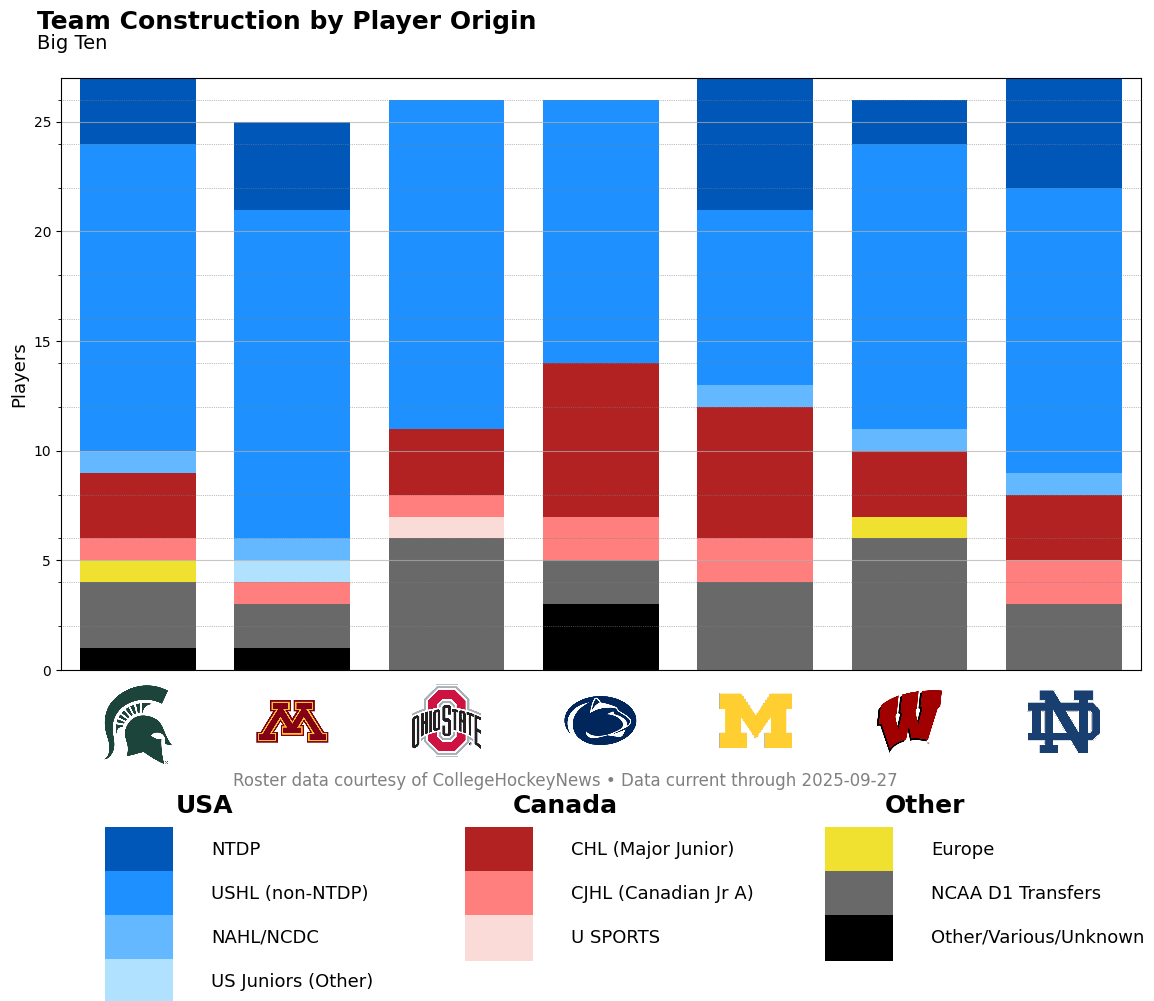

[WARN] Some teams lost rows in the pivot:
Current Team
Michigan         -73.0
Notre Dame       -73.0
Michigan State   -73.0
Ohio State       -74.0
Penn State       -74.0
Wisconsin        -74.0
Minnesota        -75.0
dtype: float64


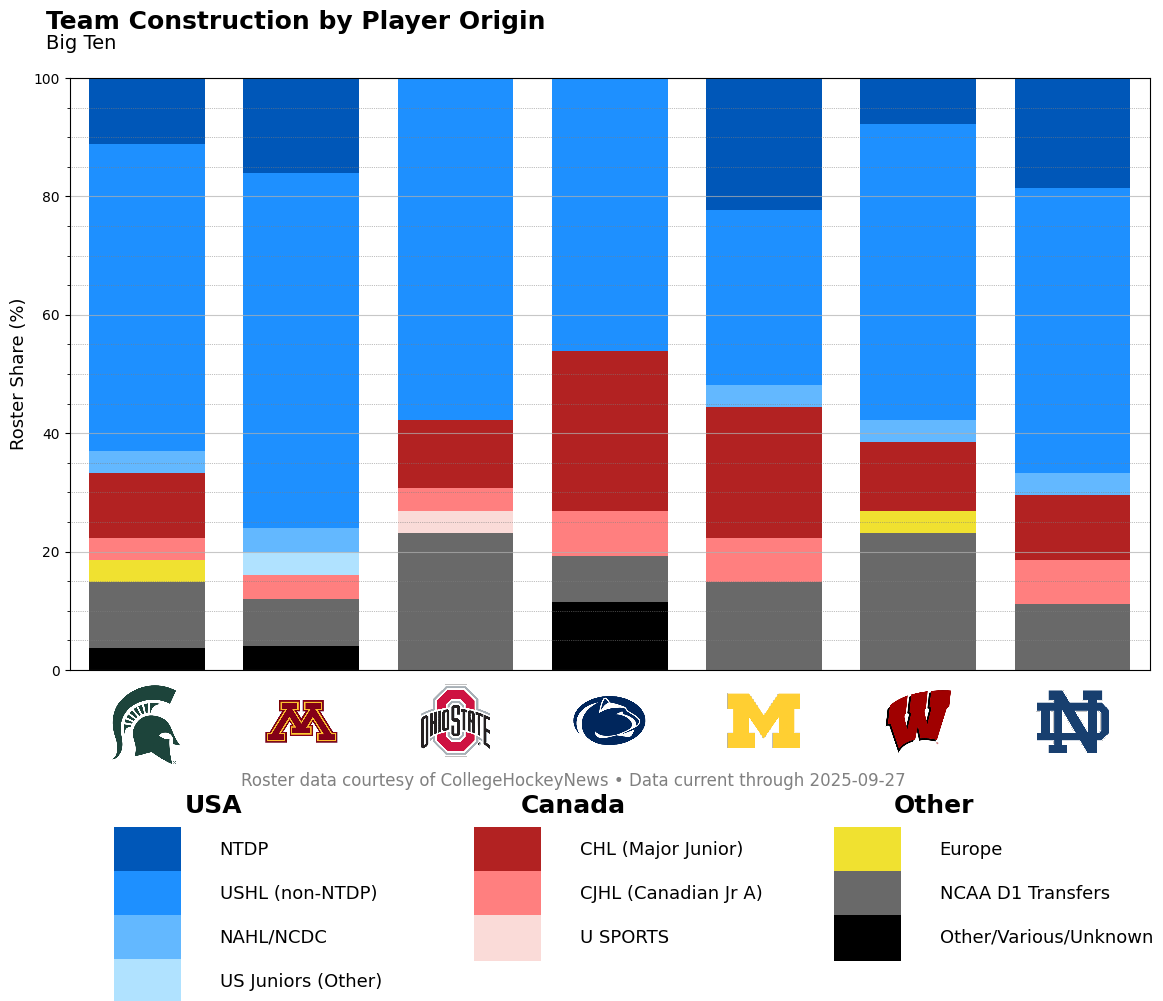

Prev_League_Bin,NTDP,USHL (non‑NTDP),NAHL/NCDC,US Juniors (Other),CHL (Major Junior),CJHL (Canadian Jr A),U SPORTS,Europe,NCAA D1 Transfers,Other/Various/Unknown
Current Team,,,,,,,,,,
Michigan State,11.111111,51.851852,3.703704,0.0,11.111111,3.703704,0.000000,3.703704,11.111111,3.703704
Minnesota,16.000000,60.000000,4.000000,4.0,0.000000,4.000000,0.000000,0.000000,8.000000,4.000000
Ohio State,0.000000,57.692308,0.000000,0.0,11.538462,3.846154,3.846154,0.000000,23.076923,0.000000
Penn State,0.000000,46.153846,0.000000,0.0,26.923077,7.692308,0.000000,0.000000,7.692308,11.538462
Michigan,22.222222,29.629630,3.703704,0.0,22.222222,7.407407,0.000000,0.000000,14.814815,0.000000
Wisconsin,7.692308,50.000000,3.846154,0.0,11.538462,0.000000,0.000000,3.846154,23.076923,0.000000
Notre Dame,18.518519,48.148148,3.703704,0.0,11.111111,7.407407,0.000000,0.000000,11.111111,0.000000


In [42]:
# Example usage (fill these in with your own data)
# big_ten = ["Michigan State","Michigan","Minnesota","Ohio State","Penn State","Wisconsin","Notre Dame"]
# logo_mapping = {"Michigan State":"msu.png", "Michigan":"um.png", ...}
# logo_folder = "/path/to/logos"
# rank_df = pairwise_df.copy()  # or None if you don't have rankings

# Counts
plot_roster_origins_conference(
    df, big_ten, "Big Ten",
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    rank_df = pairwise_df,
    normalize=False,
    save_path="",
    date_note="Data current through 2025-09-27",
)

# Percentages
plot_roster_origins_conference(
    df, big_ten, "Big Ten",
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    rank_df = pairwise_df,
    normalize=True,
    save_path="",
    date_note="Data current through 2025-09-27",
)


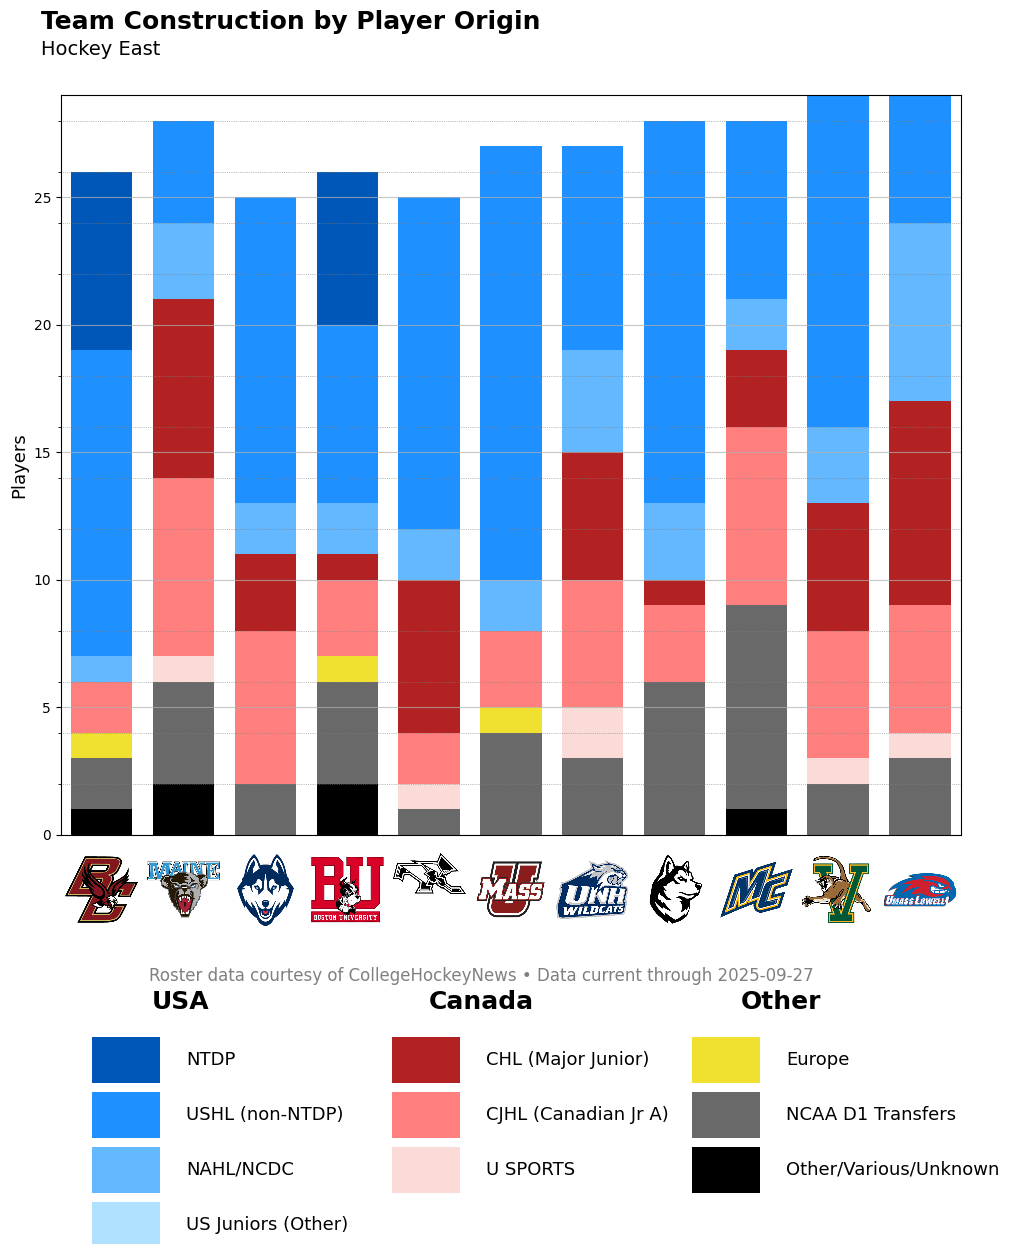

Prev_League_Bin,NTDP,USHL (non‑NTDP),NAHL/NCDC,US Juniors (Other),CHL (Major Junior),CJHL (Canadian Jr A),U SPORTS,Europe,NCAA D1 Transfers,Other/Various/Unknown
Current Team,,,,,,,,,,
Boston College,7,12,1,0,0,2,0,1,2,1
Maine,0,4,3,0,7,7,1,0,4,2
Connecticut,0,12,2,0,3,6,0,0,2,0
Boston University,6,7,2,0,1,3,0,1,4,2
Providence,0,13,2,0,6,2,1,0,1,0
Massachusetts,0,17,2,0,0,3,0,1,4,0
New Hampshire,0,8,4,0,5,5,2,0,3,0
Northeastern,0,15,3,0,1,3,0,0,6,0
Merrimack,0,7,2,0,3,7,0,0,8,1


In [43]:
# Test out on larger conference to check spacing, ect
# -----------------------------
plot_roster_origins_conference(
    df, hockey_east, "Hockey East",
    figure_size=(10, 10),
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    rank_df=rank_df,
    normalize=False,
    save_path="",
    date_note="Data current through 2025-09-27",
)


[plot] Atlantic Hockey -> c:\Users\jbanc\OneDrive\Desktop\Project\college_hockey_2526\workbook\..\TEMP\IMAGE\roster_origins_atlantic_hockey.png


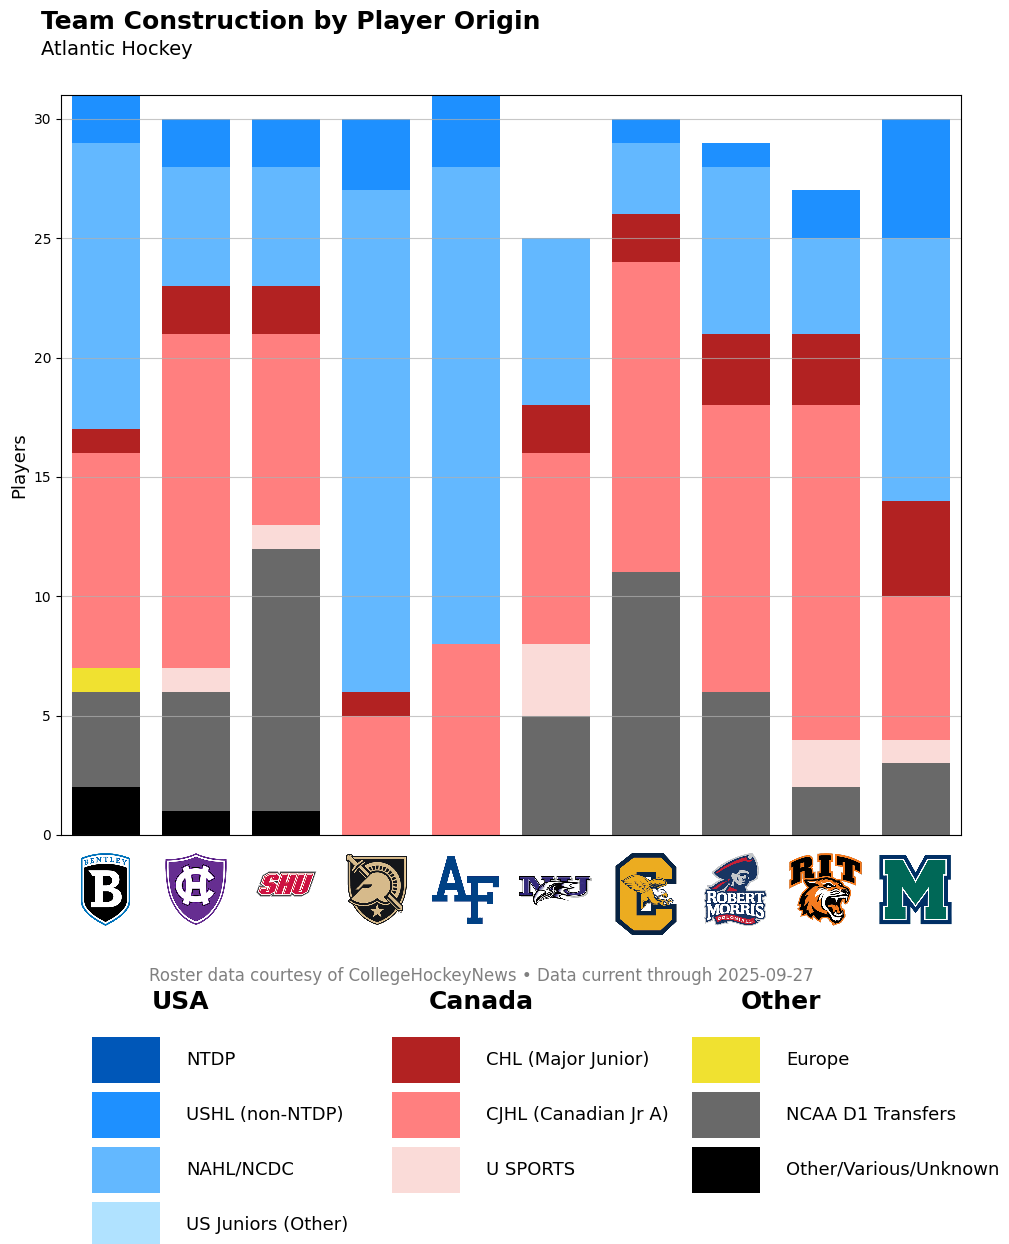

[plot] Big Ten -> c:\Users\jbanc\OneDrive\Desktop\Project\college_hockey_2526\workbook\..\TEMP\IMAGE\roster_origins_big_ten.png


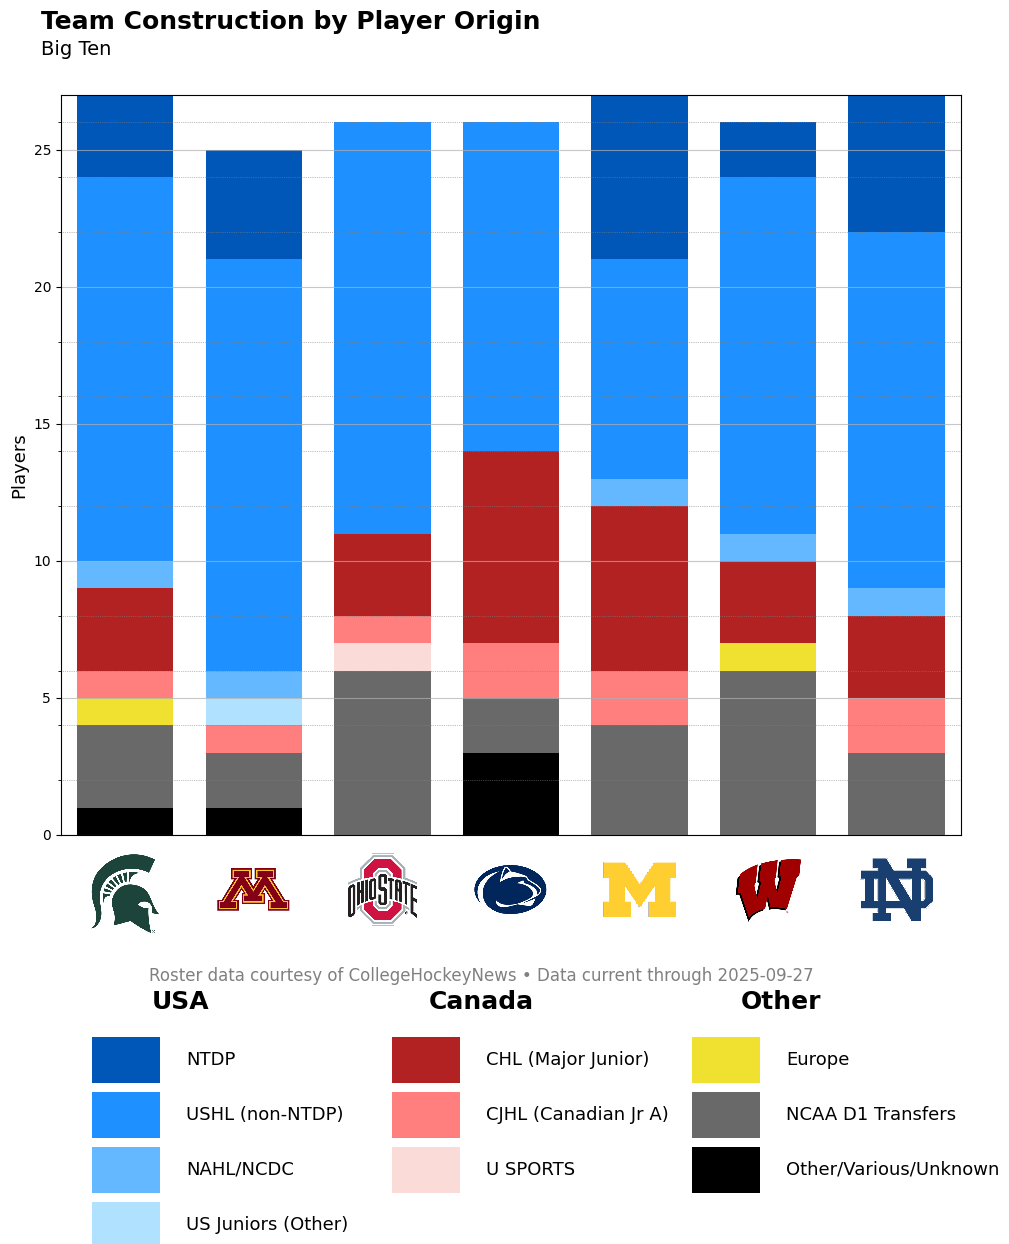

[plot] CCHA -> c:\Users\jbanc\OneDrive\Desktop\Project\college_hockey_2526\workbook\..\TEMP\IMAGE\roster_origins_ccha.png


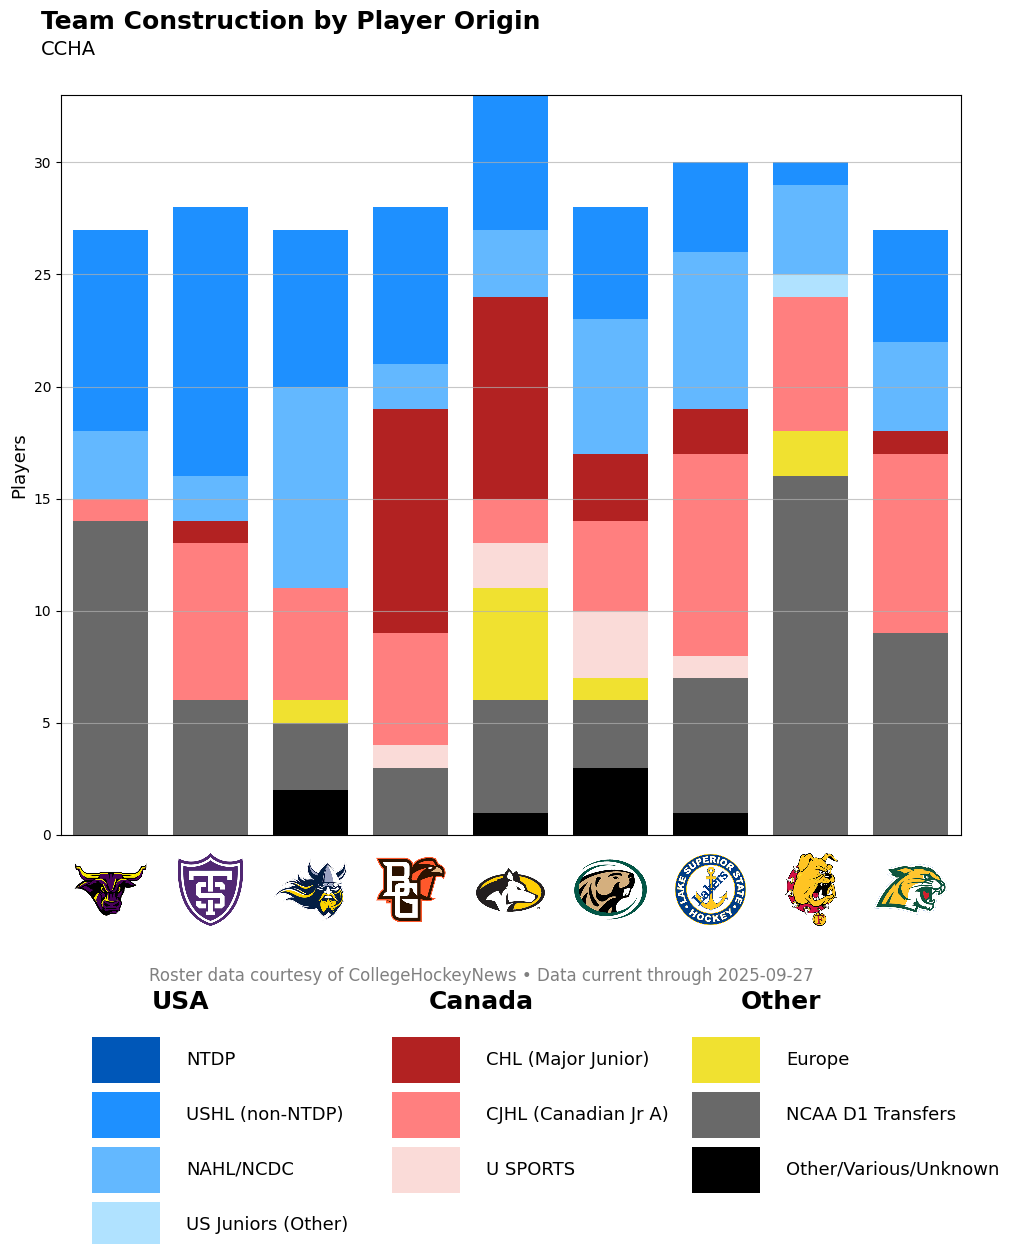

[plot] ECAC -> c:\Users\jbanc\OneDrive\Desktop\Project\college_hockey_2526\workbook\..\TEMP\IMAGE\roster_origins_ecac.png


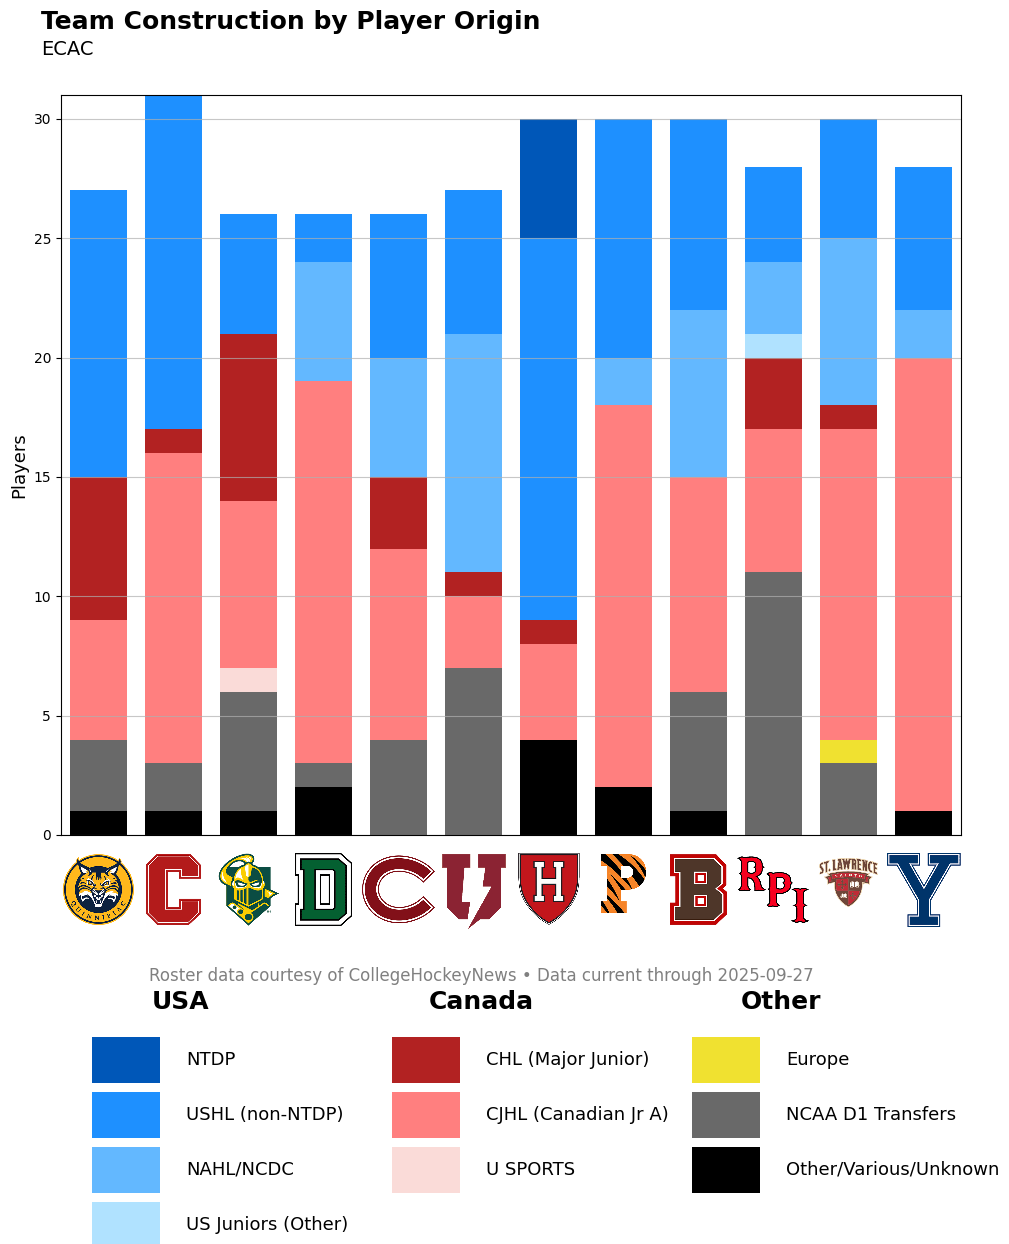

[plot] Hockey East -> c:\Users\jbanc\OneDrive\Desktop\Project\college_hockey_2526\workbook\..\TEMP\IMAGE\roster_origins_hockey_east.png


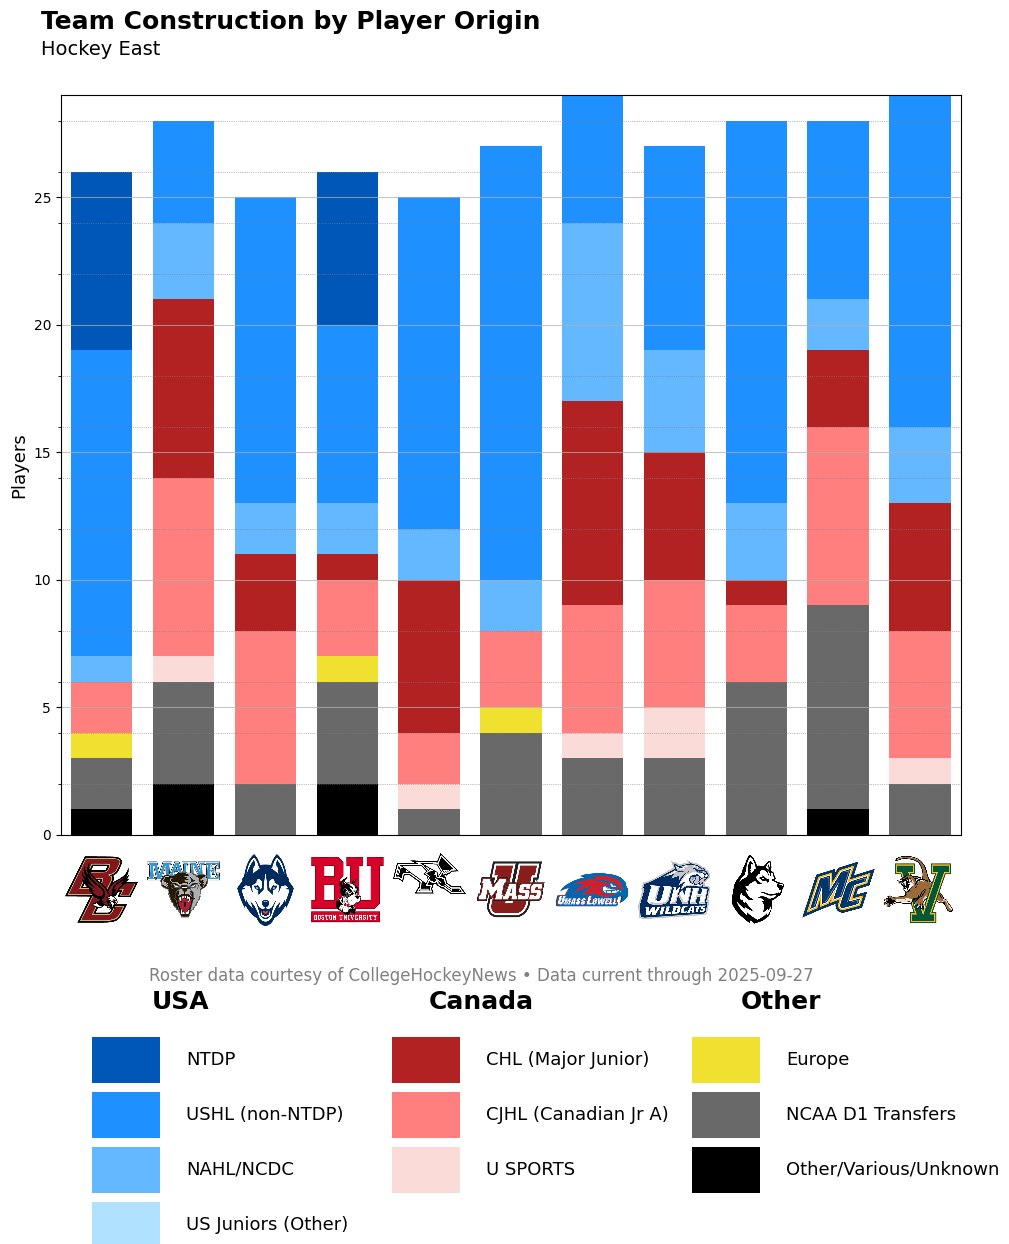

[plot] NCHC -> c:\Users\jbanc\OneDrive\Desktop\Project\college_hockey_2526\workbook\..\TEMP\IMAGE\roster_origins_nchc.png


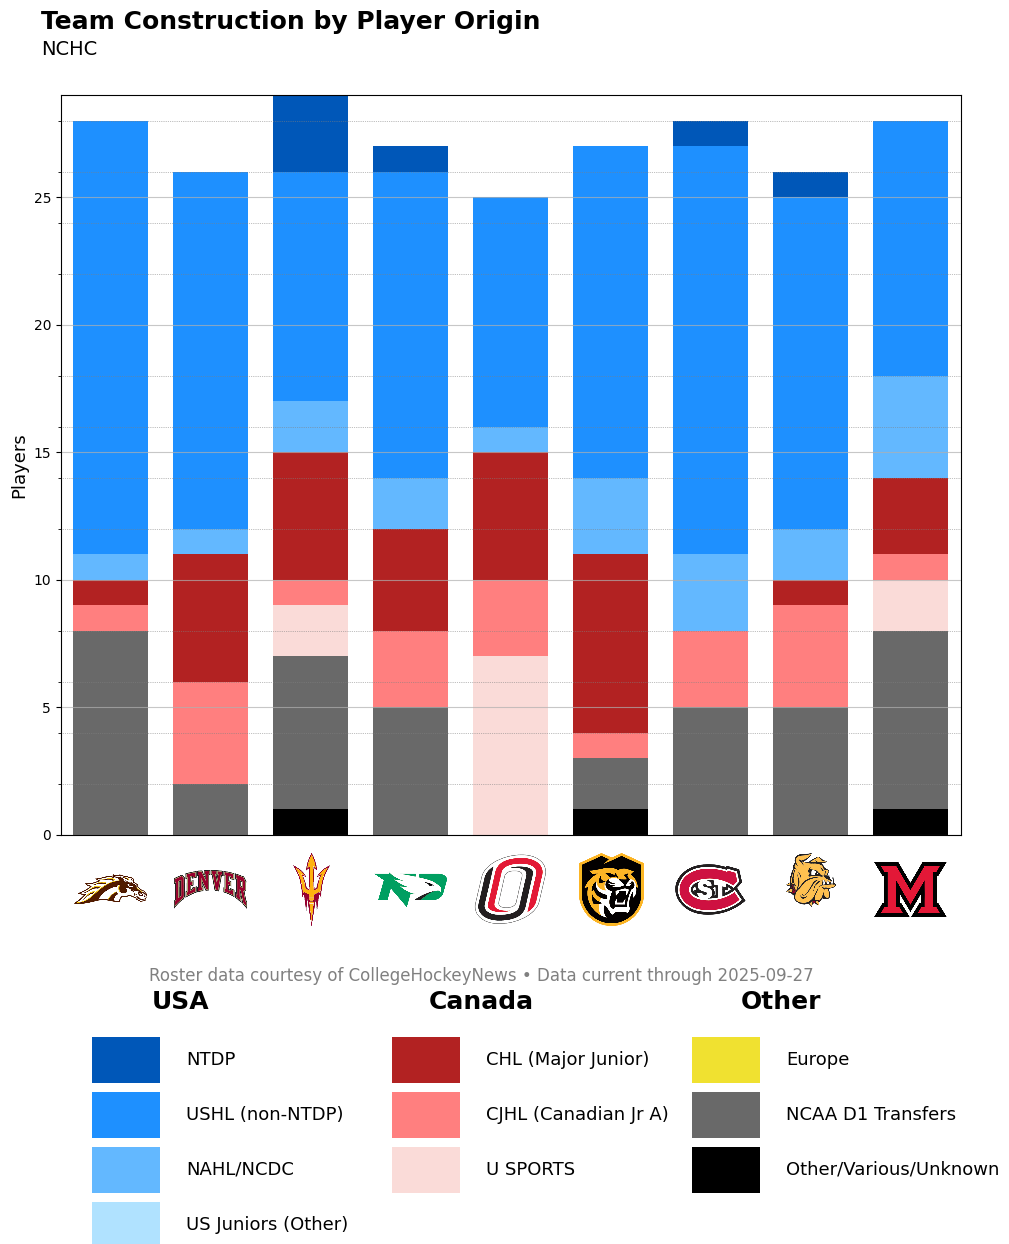

[plot] Independents -> c:\Users\jbanc\OneDrive\Desktop\Project\college_hockey_2526\workbook\..\TEMP\IMAGE\roster_origins_independents.png


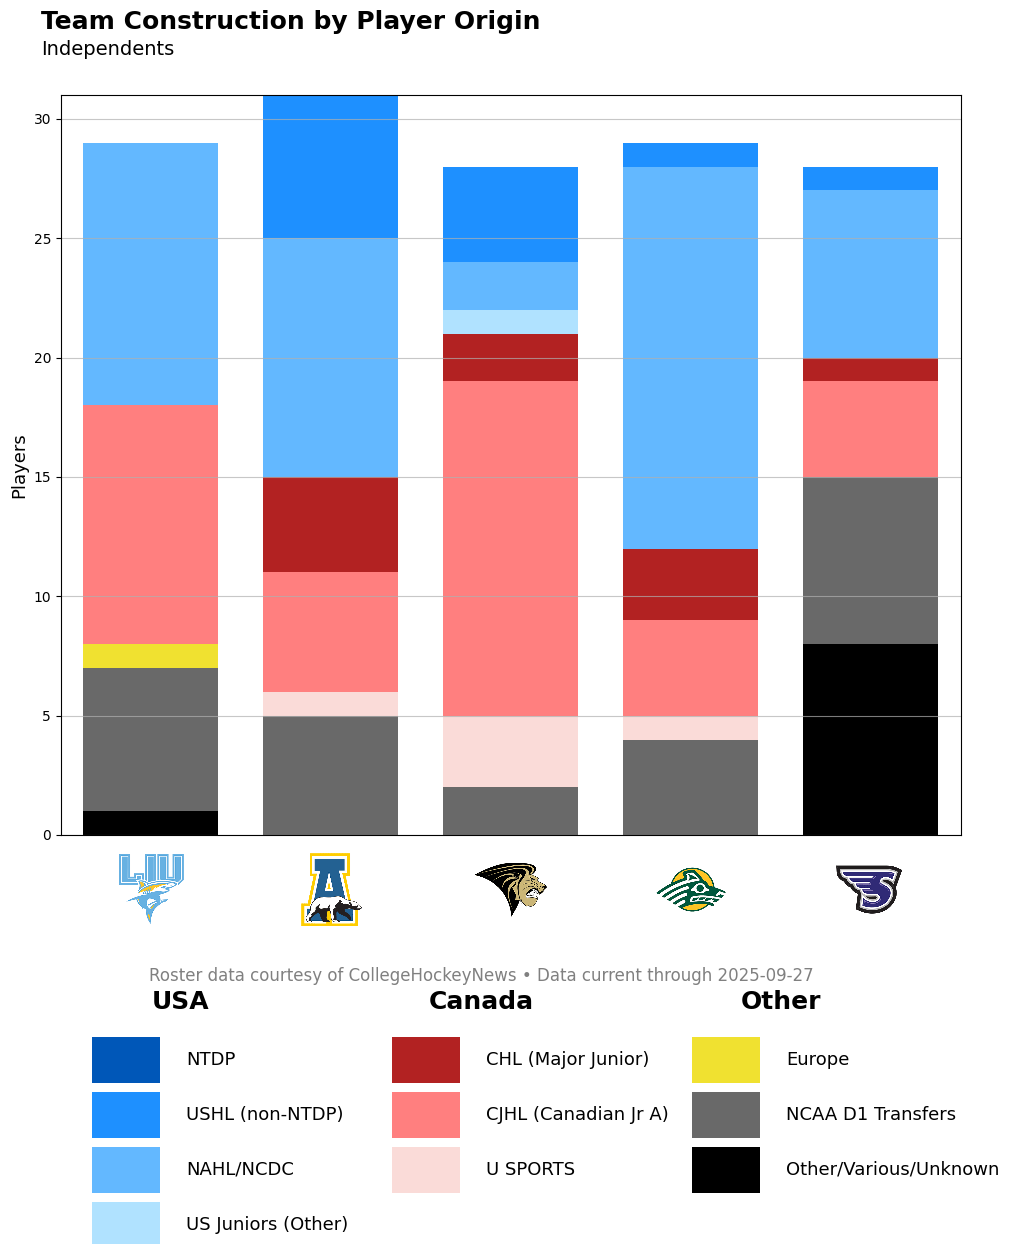

In [44]:
## Create a plot for each Conference and save it to temp_image_folder
for conf_name, conf_teams in [
    ("Atlantic Hockey", atlantic),
    ("Big Ten", big_ten),
    ("CCHA", ccha),
    ("ECAC", ecac),
    ("Hockey East", hockey_east),
    ("NCHC", nchc),
    ("Independents", independents)
]:
    out_file = os.path.join(temp_image_folder, f"roster_origins_{conf_name.replace(' ','_').lower()}.png")
    print(f"[plot] {conf_name} -> {out_file}")
    plot_roster_origins_conference(
        df, conf_teams, conf_name,
        figure_size=(10, 10),
        logo_mapping=logo_mapping,
        logo_folder=logo_folder,
        rank_df=pairwise_df,
        normalize=False,
        save_path=out_file,
        date_note="Data current through 2025-09-27",
        header_title="Team Construction by Player Origin"
    )

### LEGACY - Data Cleaning and Modifications
- Remove Trouble character from Team Names